In [1]:
import numpy as np
from scipy.stats import norm
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import os
import json

In [2]:
root_dir = '../simulations'
params_path = os.path.join(root_dir, 'map_params.json')
params = json.load(open(params_path))

# Read map parameters.
eps = params['eps']
alpha = params['alpha']
ps = {1: params['p1'], 2: params['p2']} # misclassification rates
Ns = {1: params['N1dot']*params['px_per_km2'], 2: params['N2dot']*params['px_per_km2']} # mapped areas (pixels)

true_N1 = Ns[1]*(1 - ps[1]) + Ns[2]*ps[2]
true_Ns = {1: true_N1, 2: sum(Ns.values()) - true_N1}

In [3]:
cyan = '#00eeee'

sns.set_context('paper')
sns.set_style('darkgrid')

In [4]:
sim_dir = os.path.join(root_dir, f'eps={eps},alpha={alpha},p1={ps[1]:.4f},p2={ps[2]:.4f},N1={Ns[1]:.0f},N2={Ns[2]:.0f}')

RATIO_COL = 'sampling_ratio'

REPL_COL = 'replication'
ITER_COL = 'iter'

In [5]:
%%time
ns = []
n1s = []
n2s = []
ratios = []
for sim_file in os.listdir(sim_dir):
        repl_df = pd.read_csv(os.path.join(sim_dir, sim_file), usecols=[RATIO_COL])
        n = len(repl_df)
        ratio = repl_df[RATIO_COL].values[-1]
        n2 = int(round(n / (1 + ratio)))
        n1 = n - n2

        ns.append(n)
        n1s.append(n1)
        n2s.append(n2)
        ratios.append(ratio)
    

CPU times: total: 53.2 s
Wall time: 2min 26s


In [6]:
# Optimal sample size.
z = float(norm.ppf(1 - alpha / 2))
n_opt = (z / eps * (Ns[1] * (ps[1] * (1 - ps[1]))**.5 + Ns[2] * (ps[2] * (1 - ps[2]))**.5) / true_N1)**2
n_opt


13045.002269754315

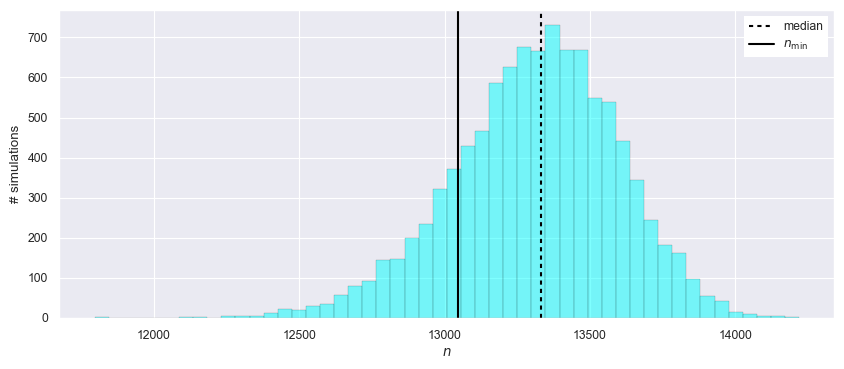

In [7]:
fig, ax = plt.subplots(figsize=(10,4))

ax = sns.histplot(ns, kde=False, lw=.1, color='cyan', alpha=.5,
                  ax=ax, edgecolor='k', bins=50)

ax.axvline(np.median(ns), color='k', lw=1.5, label='median', ls=(0, (2, 2)))
ax.axvline(n_opt, color='k', lw=1.5, label=r'$n_\text{min}$')

legend = ax.legend(fancybox=False, shadow=False, facecolor='w', framealpha=1)
legend.get_frame().set_linewidth(0)

ax.set_xlabel('$n$')
ax.set_ylabel(r'# simulations')

plt.savefig('4_simulations_n.png', bbox_inches='tight', dpi=600)

In [8]:
# Optimal ratio.
opt_ratio = true_Ns[1]*(ps[1]*(1-ps[1]))**.5 / (true_Ns[2]*(ps[2]*(1-ps[2]))**.5)
opt_ratio

0.05065108724886248

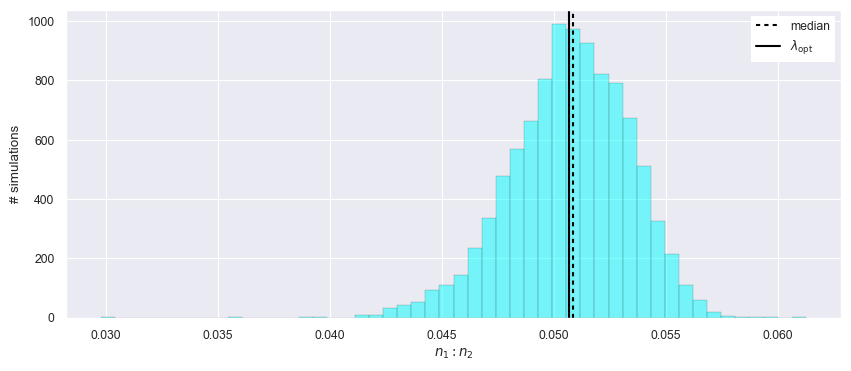

In [9]:
fig, ax = plt.subplots(figsize=(10,4))

ax = sns.histplot(ratios, kde=False, lw=.1, color='cyan', alpha=.5,
                  ax=ax, edgecolor='k', bins=50)

ax.axvline(np.median(ratios), color='k', lw=1.5, label='median', ls=(0, (2, 2)))
ax.axvline(opt_ratio, color='k', lw=1.5, label=r'$\lambda_\text{opt}$')

legend = ax.legend(fancybox=False, shadow=False, facecolor='w', framealpha=1)
legend.get_frame().set_linewidth(0)

ax.set_xlabel(r'$\frac{n_1}{n_2}$')
ax.set_xlabel(r'$n_1:n_2$')
ax.set_ylabel(r'# simulations')

plt.savefig('5_simulations_ratio.png', bbox_inches='tight', dpi=600)